# Lecture: Implementation of Monte Carlo Policy Evaluation for Blackjack

We want to implement monte carlo policy evaluation for the `blackjack` environment provided by gymnasium.

Blackjack is a card game in which the aim is to beat the dealer by getting cards that total closer to 21 (without totalling over 21) than the dealer's cards. The game begins with the dealer having one face-up and one face-down card, while the player has two face-up cards. All cards are drawn from an infinite deck (i.e. with replacements).

- Face cards (Jack, Queen, King) have a point value of 10.
- Aces can count either as 11 (a so-called "usable ace") or as 1.
- Numerical cards (2-9) have a value corresponding to their number.

The player sees the sum of the cards held. He can request more cards (hit) until he decides to stop (stick) or exceed 21 (bust, immediate loss).
After the player has stopped, the dealer reveals his face-down card and draws cards until the total is 17 or more. If the dealer goes bust, the player wins.
If neither the player nor the dealer busts, the result (win, loss, tie) is determined by whose total is closer to 21.
To analyse different strategies, we use the gymnasium environment `Blackjack-v1`, the description of which can be found [here](https://gymnasium.farama.org/environments/toy_text/blackjack/).

In [ ]:
!git clone https://github.com/Fjoelsak/RL.git
!cp RL/04_Mode_free_prediction/mc_eval_agent.py ./

### Excercises

#### Task 1: Getting to know the environment

Go to the [farama foundation documentation](https://gymnasium.farama.org/environments/toy_text/blackjack/) and determine how the state and action spaces are defined, how the reward function is implemented and how the condition for a termination of the episode is implemented. Which actions are coded here and how, and what information does an agent receive with the given definition of the observations?

In [1]:
import gymnasium as gym

env = gym.make('Blackjack-v1')

# Checking action and state space
print(env.observation_space)
print(env.action_space)

Tuple(Discrete(32), Discrete(11), Discrete(2))
Discrete(2)


#### Task 2

Play ten time steps as an agent with randomised actions and look at the actions, observations and rewards for each time step.
	Also display the end of each episode.
	Try to reproduce the individual games according to the rules mentioned above.

In [1]:
import gymnasium as gym
import pygame
import time

env = gym.make("Blackjack-v1", render_mode="human")

# Number of time steps the agent plays
num_steps = 10

obs, _ = env.reset()
print("Initial observation: ", obs)

for step in range(num_steps):
    # Choosing a randomized action
    action = env.action_space.sample()

    # Apply the action to the env
    observation, reward, terminated, truncated, info = env.step(action)

    # Render env
    env.render()

    # Short waiting to see the video
    time.sleep(0.01)

    print("Action: ", "Hit" if action == 1 else "Stick", "  Observation: ", observation, "  Reward: ", reward)
    # reset if the game is over
    if terminated or truncated:
        print("Episode is finished!"+"\n")
        observation, _ = env.reset()
        print("Initial observation: ", observation)

    for event in pygame.event.get():
            if event.type == pygame.KEYDOWN:
                if event.key == pygame.K_q:  # Beenden, wenn q-Taste gedrückt wird
                    pygame.quit()

# Close the env
env.close()

Initial observation:  (10, 5, 0)
Action:  Hit   Observation:  (21, 5, 1)   Reward:  0.0
Action:  Hit   Observation:  (13, 5, 0)   Reward:  0.0
Action:  Hit   Observation:  (23, 5, 0)   Reward:  -1.0
Episode is finished!

Initial observation:  (14, 2, 1)
Action:  Hit   Observation:  (16, 2, 1)   Reward:  0.0
Action:  Stick   Observation:  (16, 2, 1)   Reward:  -1.0
Episode is finished!

Initial observation:  (20, 5, 0)
Action:  Stick   Observation:  (20, 5, 0)   Reward:  1.0
Episode is finished!

Initial observation:  (19, 2, 0)
Action:  Stick   Observation:  (19, 2, 0)   Reward:  -1.0
Episode is finished!

Initial observation:  (16, 6, 1)
Action:  Stick   Observation:  (16, 6, 1)   Reward:  -1.0
Episode is finished!

Initial observation:  (12, 5, 1)
Action:  Stick   Observation:  (12, 5, 1)   Reward:  1.0
Episode is finished!

Initial observation:  (14, 3, 0)
Action:  Stick   Observation:  (14, 3, 0)   Reward:  -1.0
Episode is finished!

Initial observation:  (20, 6, 0)


#### Task 3

 Implement the policy presented in the lecture, in which you always draw a card as long as the sum of your cards is less than or equal to 19.
	Test your new policy with the setup defined in task 2 and follow the individual steps.

In [2]:
import gymnasium as gym
import time

# Initiale Policy: Immer Hit, wenn Score <= 19
def initial_policy(observation):
    score, dealer_score, usable_ace = observation
    return 1 if score <= 19 else 0

env = gym.make("Blackjack-v1", render_mode="human")

# Number of time steps the agent plays
num_steps = 10

observation, _ = env.reset()
print("Initial observation: ", observation)

for step in range(num_steps):
    action = initial_policy(observation)
    observation, reward, terminated, truncated, info = env.step(action)

    env.render()

    time.sleep(0.01)

    print("Action: ", "Hit" if action == 1 else "Stick", "  Observation: ", observation, "  Reward: ", reward)
    # reset if the game is over
    if terminated or truncated:
        print("Episode is finished!"+"\n")
        observation, _ = env.reset()
        print("Initial observation: ", observation)

# Close the env
env.close()

Initial observation:  (11, 10, 0)
Action:  Hit   Observation:  (20, 10, 0)   Reward:  0.0
Action:  Stick   Observation:  (20, 10, 0)   Reward:  1.0
Episode is finished!

Initial observation:  (10, 4, 0)
Action:  Hit   Observation:  (15, 4, 0)   Reward:  0.0
Action:  Hit   Observation:  (16, 4, 0)   Reward:  0.0
Action:  Hit   Observation:  (26, 4, 0)   Reward:  -1.0
Episode is finished!

Initial observation:  (15, 9, 0)
Action:  Hit   Observation:  (25, 9, 0)   Reward:  -1.0
Episode is finished!

Initial observation:  (18, 1, 1)
Action:  Hit   Observation:  (20, 1, 1)   Reward:  0.0
Action:  Stick   Observation:  (20, 1, 1)   Reward:  1.0
Episode is finished!

Initial observation:  (13, 10, 0)
Action:  Hit   Observation:  (16, 10, 0)   Reward:  0.0
Action:  Hit   Observation:  (20, 10, 0)   Reward:  0.0


#### Task 4

Now refactor your code. We want to have a separate class, an `MCEvalAgent`. Implement the function `gen_eps(env, policy)` in `mc_eval_agent.py` that runs through a single episode for the policy defined above and the current environment. While running through an episode, save all `states`, `actions` and `rewards` and return them as return values in the form of three lists. Test your refactored code by playing blackjack with 3 episodes and outputting the corresponding states, actions and rewards.

Note: don't forget to reset the environment at the beginning of generating an episode.

In [1]:
import gymnasium as gym
import time
from mc_eval_agent_sol import MCEvalAgent

env = gym.make("Blackjack-v1", render_mode="human")

# Number of episodes the agent plays
num_eps = 4

# Initiale Policy: always Hit, if score <= 19
def initial_policy(observation):
    score, dealer_score, usable_ace = observation
    return 1 if score <= 19 else 0

# Init a MC agent
agent = MCEvalAgent(0.9)

for step in range(num_eps):
    # generate episodes
    states, actions, rewards = agent.gen_eps(env, initial_policy)
    print("States: ", states)
    print("Actions: ", actions)
    print("Rewards: ", rewards)
    print("")

# Close the env
env.close()

States:  [(15, 10, 0)]
Actions:  [1]
Rewards:  [-1.0]

States:  [(13, 7, 0), (19, 7, 0)]
Actions:  [1, 1]
Rewards:  [0.0, -1.0]

States:  [(11, 10, 0), (19, 10, 0)]
Actions:  [1, 1]
Rewards:  [0.0, -1.0]

States:  [(9, 9, 0), (13, 9, 0), (19, 9, 0)]
Actions:  [1, 1, 1]
Rewards:  [0.0, 0.0, -1.0]



#### Task 5

Then implement the first-visit monte carlo policy evaluation algorithm in the function `eval(env, n_episodes, policy)`, which calculates the mean values of the values of the respective states for the specified number of episodes. $\gamma$ shall be 0.9.

In [2]:
import gymnasium as gym
import time
from mc_eval_agent_sol import MCEvalAgent

env = gym.make("Blackjack-v1")

# Initiale Policy: Immer Hit, wenn Score <= 19
def initial_policy(observation):
    score, dealer_score, usable_ace = observation
    return 1 if score <= 19 else 0

agent = MCEvalAgent(0.9)
value = agent.eval(env, 500000, initial_policy)
env.close()


Use the given plot function `plot_blackjack(V)` to visualise the figures from the lecture, i.e. the evaluation functions for n eps= 10,000 and 500,000.

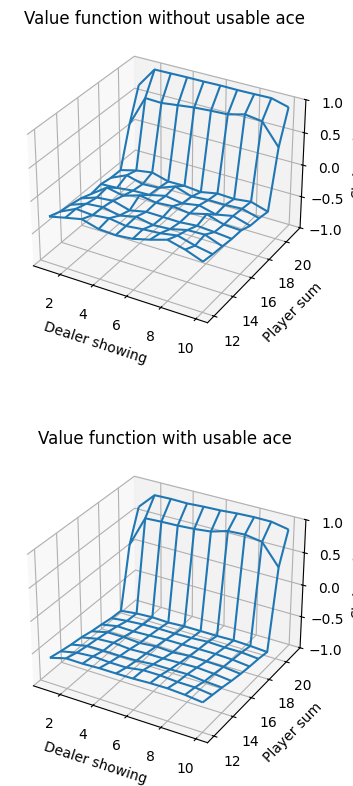

In [3]:
agent.plot_blackjack(value)

#### Task 6

We consider the following policy: if the sum of the player cards is greater than 18, we choose the action Stick with 80% probability and the action Hit with
20% probability. If the sum of the player cards is less than or equal to 18, we choose the action Stick with 20% probability and the action Hit with 80% probability
. What does the state value function look like?

In [4]:
import numpy as np

# stochastic Policy:
# if score > 18, 80% Hit, 20% Stick
# if Score <= 18, 20% Hit, 80% Stick
def stoch_policy(obs):
    player_sum = obs[0]
    probs = [0.8, 0.2] if player_sum > 18 else [0.2, 0.8]
    return np.random.choice(np.arange(2), p=probs)


In [5]:
import gymnasium as gym
import time
from mc_eval_agent_sol import MCEvalAgent

env = gym.make("Blackjack-v1")

agent = MCEvalAgent(0.9)
value = agent.eval(env, 500000, stoch_policy)

env.close()

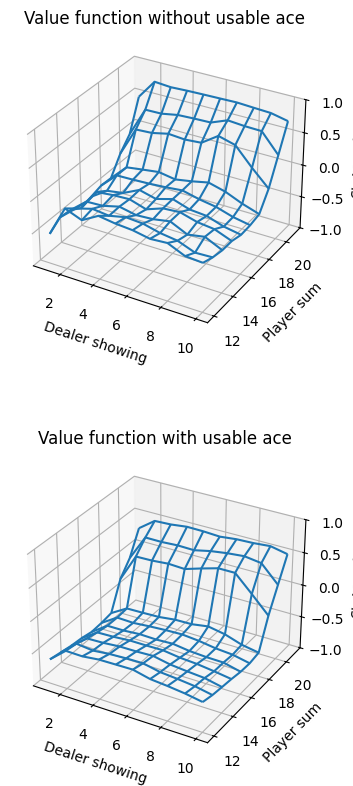

In [6]:
agent.plot_blackjack(value)